In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from prophet import Prophet
%matplotlib inline

In [15]:
df_bolsa = yf.download('SPY', start='2020-01-01', end='2026-03-03')

[*********************100%***********************]  1 of 1 completed


In [16]:
df_bolsa.reset_index(inplace=True)

In [17]:
df_bolsa.tail()

Price,Date,Close,High,Low,Open,Volume
Ticker,,SPY,SPY,SPY,SPY,SPY
1543,2026-02-24,687.349976,688.349976,680.000000,681.900024,73798700
1544,2026-02-25,693.150024,693.679993,690.099976,690.179993,56369500
1545,2026-02-26,689.299988,693.299988,684.349976,693.280029,71671000
1546,2026-02-27,685.989990,686.859985,681.640015,683.090027,83308900
1547,2026-03-02,686.380005,688.619995,678.020020,678.700012,87477200


In [18]:
df_prophet = df_bolsa[['Date', 'Close']].copy()
df_prophet.columns = ['ds', 'y']

In [22]:
df_prophet.head()

,ds,y
0,2020-01-02,297.699036
1,2020-01-03,295.444763
2,2020-01-06,296.571838
3,2020-01-07,295.738007
4,2020-01-08,297.314148


In [19]:
df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)

11:16:00 - cmdstanpy - INFO - Chain [1] start processing
11:16:00 - cmdstanpy - INFO - Chain [1] done processing


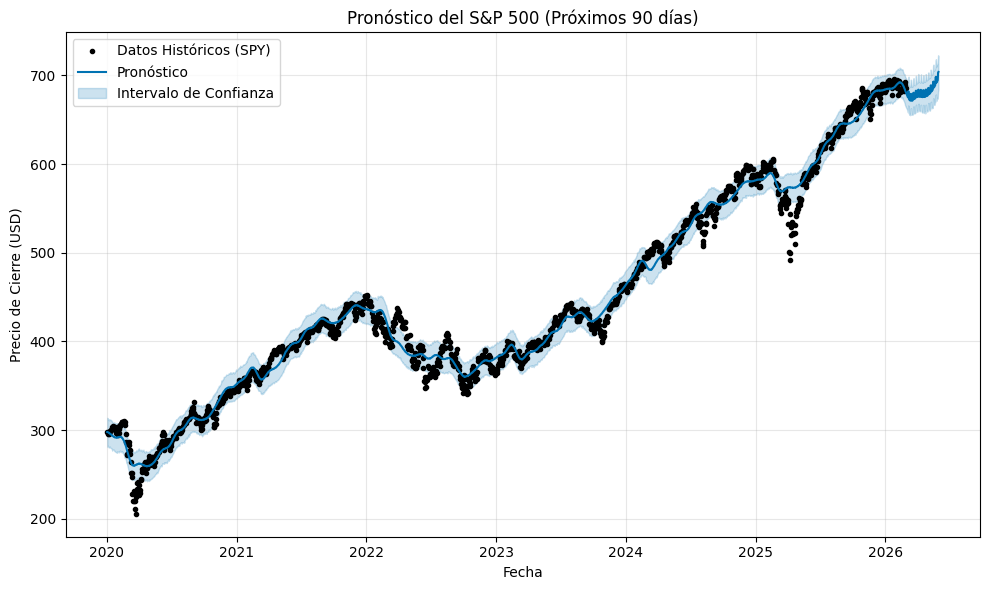

In [30]:
modelo_prophet = Prophet(daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True)
modelo_prophet.fit(df_prophet)

calendario_futuro = modelo_prophet.make_future_dataframe(periods=90)
prediccion = modelo_prophet.predict(calendario_futuro)

fechas_historicas = modelo_prophet.history['ds'].to_numpy()
valores_historicos = modelo_prophet.history['y'].to_numpy()

fechas_futuras = prediccion['ds'].to_numpy()
pred_principal = prediccion['yhat'].to_numpy()
limite_inferior = prediccion['yhat_lower'].to_numpy()
limite_superior = prediccion['yhat_upper'].to_numpy()


plt.figure(figsize=(10, 6))

plt.plot(fechas_historicas, valores_historicos, 'k.', label='Datos Históricos (SPY)')

plt.plot(fechas_futuras, pred_principal, ls='-', c='#0072B2', label='Pronóstico')

plt.fill_between(fechas_futuras, limite_inferior, limite_superior, color='#0072B2', alpha=0.2, label='Intervalo de Confianza')

plt.title('Pronóstico del S&P 500 (Próximos 90 días)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


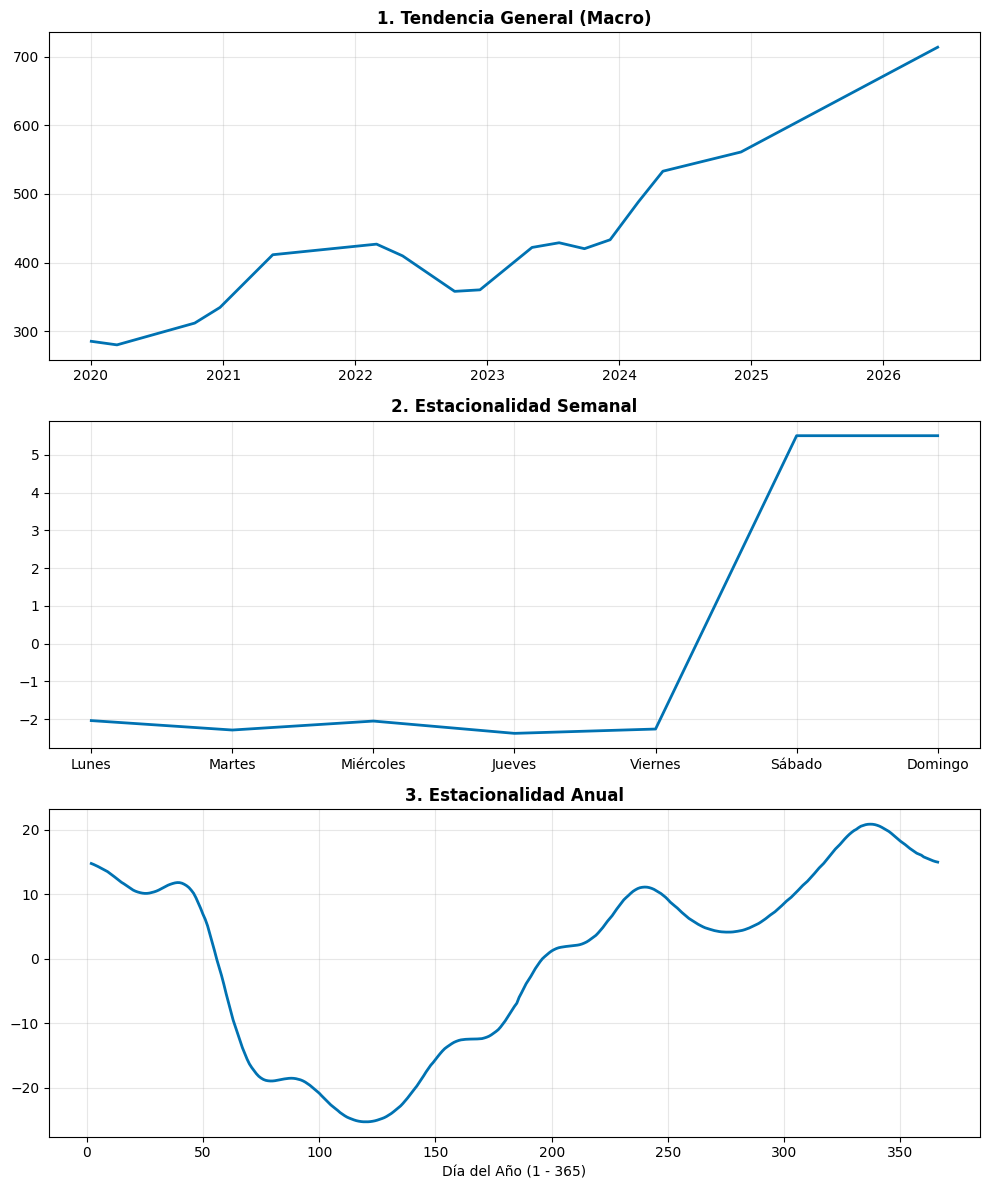

In [31]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

tendencia_numpy = prediccion['trend'].to_numpy()
axs[0].plot(fechas_futuras, tendencia_numpy, ls='-', c='#0072B2', linewidth=2)
axs[0].set_title('1. Tendencia General (Macro)', fontweight='bold')
axs[0].grid(True, alpha=0.3)

prediccion['dia_semana'] = prediccion['ds'].dt.dayofweek
semanal = prediccion.groupby('dia_semana')['weekly'].mean()
dias_nombres = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
axs[1].plot(dias_nombres, semanal.to_numpy(), ls='-', c='#0072B2', linewidth=2)
axs[1].set_title('2. Estacionalidad Semanal', fontweight='bold')
axs[1].grid(True, alpha=0.3)

prediccion['dia_ano'] = prediccion['ds'].dt.dayofyear
anual = prediccion.groupby('dia_ano')['yearly'].mean()
axs[2].plot(anual.index.to_numpy(), anual.to_numpy(), ls='-', c='#0072B2', linewidth=2)
axs[2].set_title('3. Estacionalidad Anual', fontweight='bold')
axs[2].set_xlabel('Día del Año (1 - 365)')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


valores_reales = df_prophet['y'].to_numpy()
valores_predichos = prediccion['yhat'][:len(valores_reales)].to_numpy()

mae = mean_absolute_error(valores_reales, valores_predichos)
error_porcentual = (mae / valores_reales.mean()) * 100
rmse = np.sqrt(mean_squared_error(valores_reales, valores_predichos))
mape = mean_absolute_percentage_error(valores_reales, valores_predichos) * 100

print("--- MÉTRICAS DE RENDIMIENTO (PROPHET) ---")
print(f"Precio Promedio SPY: ${valores_reales.mean():.2f}")
print(f"MAE:                 ${mae:.2f}")
print(f"Margen Relativo:     {error_porcentual:.2f}%")
print(f"RMSE (Castigo a errores grandes): ${rmse:.2f}")
print(f"MAPE (Promedio porcentual diario): {mape:.2f}%")

--- MÉTRICAS DE RENDIMIENTO (PROPHET) ---
Precio Promedio SPY: $447.28
MAE:                 $8.96
Margen Relativo:     2.00%
RMSE (Castigo a errores grandes): $12.41
MAPE (Promedio porcentual diario): 2.14%
